# 06 -- Design Catalog

Explore the trade-off space between aerodynamic performance and manufacturability:

1. **Build catalog** — baseline, v2 optimized, and alpha-blended designs
2. **Aero evaluation** — 10-target surrogate (with CG correction + control derivatives)
3. **Manufacturability scoring** — curvature, thickness, mold complexity
4. **Pareto analysis** — L/D vs. manufacturability trade-off front
5. **Geometric comparison** — planform overlays, radar charts
6. **STEP export** — batch export for downstream structural/manufacturing pipeline

In [1]:
import sys
sys.path.insert(0, '..')

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from src.config import load_all
from src.optimization.catalog import DesignCatalog
from src.evaluation.manufacturability import compute_manufacturability
from src.visualization.comparison import (
    plot_pareto, plot_radar, plot_planform_overlay, plot_summary_table,
)

from src.visualization.style import apply_style, COLORS
apply_style()

cfg = load_all()
mission = cfg['mission']
feasibility = cfg['feasibility']

## 1. Build the Design Catalog

Two reference points + 4 interpolated designs spanning the full trade-off spectrum.

In [2]:
catalog = DesignCatalog()

# ── Reference designs ──
catalog.add_baseline()

# Load v2 optimized design
try:
    catalog.add_optimized('../output/best_x_v2.npy')
    print('Using v2 optimized design')
except FileNotFoundError:
    catalog.add_optimized('../output/best_x.npy')
    print('Using v1 design (fallback)')

# ── Top feasible designs from the LHS dataset ──
from src.optimization.database import EvaluationDatabase

db = EvaluationDatabase.load('../data/eval_database.json')
X_arr, results = db.to_arrays()

# Find top 5 feasible designs by L/D (diverse)
feasible_idx = [i for i, r in enumerate(results) 
                if r.get('is_feasible', False) and r.get('L_over_D', 0) > 0]
feasible_idx.sort(key=lambda i: -results[i]['L_over_D'])

# Add top 5 with diversity filter (min distance between designs)
from src.parameterization.design_variables import get_bounds_arrays
lb, ub = get_bounds_arrays()
diag = np.linalg.norm(ub - lb)
selected = []
for idx in feasible_idx:
    x = X_arr[idx]
    # Skip if too close to an already selected design
    if any(np.linalg.norm(x - s) / diag < 0.05 for s in selected):
        continue
    selected.append(x)
    name = f'lhs_top{len(selected)}'
    catalog.add(name, x, origin='dataset', tags=['lhs'])
    if len(selected) >= 5:
        break

print(f'Added {len(selected)} top feasible designs from LHS dataset')

# ── Alpha-blends between best LHS and optimized ──
if len(selected) > 0:
    best_lhs = f'lhs_top1'
    catalog.interpolate(best_lhs, 'optimized', [0.33, 0.67])

print(f'\nCatalog: {len(catalog)} designs')
for e in catalog:
    p = e.params
    print(f'  {e.name:20s}  span={2*p.half_span:.2f}m  t/c={p.body_tc_root:.3f}  '
          f'taper={p.taper_ratio:.3f}  sweep={p.le_sweep_deg:.1f}')

Using v2 optimized design
Added 5 top feasible designs from LHS dataset

Catalog: 9 designs
  baseline              span=1.50m  t/c=0.181  taper=0.150  sweep=26.0
  optimized             span=1.16m  t/c=0.177  taper=0.233  sweep=26.0
  lhs_top1              span=1.17m  t/c=0.205  taper=0.227  sweep=29.9
  lhs_top2              span=1.35m  t/c=0.208  taper=0.151  sweep=33.9
  lhs_top3              span=1.16m  t/c=0.181  taper=0.361  sweep=29.2
  lhs_top4              span=1.60m  t/c=0.159  taper=0.253  sweep=28.4
  lhs_top5              span=1.60m  t/c=0.177  taper=0.221  sweep=34.1
  blend_33              span=1.16m  t/c=0.196  taper=0.229  sweep=28.6
  blend_67              span=1.16m  t/c=0.186  taper=0.231  sweep=27.3


## 2. Aerodynamic Evaluation (Surrogate)

Instant evaluation via the pre-trained MLP ensemble (7 VLM primitives → full reconstruction).

In [3]:
catalog.evaluate_aero(
    mission=mission,
    feasibility=feasibility,
    use_surrogate=False,  # AVL validation — surrogat has 30% L/D gap
)

  baseline              L/D= 10.38  X
  optimized             L/D= 18.82  OK
  lhs_top1              L/D= 16.81  OK
  lhs_top2              L/D= 16.68  OK
  lhs_top3              L/D= 15.91  OK
  lhs_top4              L/D= 15.51  OK
  lhs_top5              L/D= 15.50  OK
  blend_33              L/D= 17.45  OK
  blend_67              L/D= 18.14  OK


## 3. Manufacturability Scoring

Geometric metrics quantifying fabrication difficulty: twist/dihedral gradients, minimum thickness, mold complexity, taper severity.

In [4]:
catalog.evaluate_manufacturability()

# Detailed breakdown for baseline vs optimized
for name in ['baseline', 'optimized']:
    e = catalog[name]
    mm = e.manufacturing_metrics
    print(f'\n=== {name.upper()} (score={mm["manufacturability_score"]:.3f}) ===')
    for k, v in mm.items():
        if k.startswith('sub_'):
            print(f'  {k[4:]:25s}  {v:.3f}')
    print(f'  {"twist_gradient_max":25s}  {mm["twist_gradient_max"]:.1f} °/m')
    print(f'  {"dihedral_gradient_max":25s}  {mm["dihedral_gradient_max"]:.1f} °/m')
    print(f'  {"thickness_tip_mm":25s}  {mm["thickness_tip_mm"]:.1f} mm')
    print(f'  {"n_dihedral_breaks":25s}  {mm["n_dihedral_breaks"]}')

  baseline              manuf=0.631
  optimized             manuf=0.438
  lhs_top1              manuf=0.417
  lhs_top2              manuf=0.228
  lhs_top3              manuf=0.555
  lhs_top4              manuf=0.381
  lhs_top5              manuf=0.293
  blend_33              manuf=0.406
  blend_67              manuf=0.460

=== BASELINE (score=0.631) ===
  twist_smoothness           0.593
  dihedral_smoothness        0.159
  dihedral_simplicity        0.667
  tip_robustness             0.912
  taper_simplicity           0.412
  blend_smoothness           0.857
  sweep_continuity           0.778
  twist_simplicity           0.900
  equipment_space            0.173
  mold_size                  1.000
  twist_gradient_max         11.1 °/m
  dihedral_gradient_max      88.9 °/m
  thickness_tip_mm           7.6 mm
  n_dihedral_breaks          1

=== OPTIMIZED (score=0.438) ===
  twist_smoothness           0.000
  dihedral_smoothness        0.000
  dihedral_simplicity        1.000
  tip_robustn

## 4. Summary Table

In [5]:
from src.geometry.control_surfaces import compute_control_surface_geometry

print(catalog.summary())
print()

# Pandas DataFrame for detailed comparison
df = catalog.to_dataframe()

# Add control surface dimension columns
elevon_spans = []
aileron_spans = []
for e in catalog:
    cs_list = compute_control_surface_geometry(e.params)
    ev_span = 0.0
    ai_span = 0.0
    for cs in cs_list:
        if 'elevon' in cs.name.lower():
            ev_span = cs.span * 100  # m -> cm
        elif 'aileron' in cs.name.lower():
            ai_span = cs.span * 100  # m -> cm
    elevon_spans.append(ev_span)
    aileron_spans.append(ai_span)

df['elevon_span_cm'] = elevon_spans
df['aileron_span_cm'] = aileron_spans

cols = ['origin', 'L_over_D', 'static_margin', 'is_feasible',
        'manuf_manufacturability_score', 'struct_mass', 'endurance_min',
        'half_span', 'body_tc_root', 'taper_ratio',
        'elevon_deflection', 'Cl_beta', 'x_cg_frac',
        'elevon_span_cm', 'aileron_span_cm']
display(df[[c for c in cols if c in df.columns]].round(3))

DesignCatalog: 9 designs

Name                 Origin            L/D  Feas  Manuf Tags
------------------------------------------------------------
baseline             default         10.38     X  0.631 baseline, reference
optimized            optimization    18.82    OK  0.438 optimized, reference, feasible
lhs_top1             dataset         16.81    OK  0.417 lhs, feasible
lhs_top2             dataset         16.68    OK  0.228 lhs, feasible
lhs_top3             dataset         15.91    OK  0.555 lhs, feasible
lhs_top4             dataset         15.51    OK  0.381 lhs, feasible
lhs_top5             dataset         15.50    OK  0.293 lhs, feasible
blend_33             interpolation   17.45    OK  0.406 blend, alpha=0.33, feasible
blend_67             interpolation   18.14    OK  0.460 blend, alpha=0.67, feasible



,origin,L_over_D,static_margin,is_feasible,manuf_manufacturability_score,struct_mass,endurance_min,half_span,body_tc_root,taper_ratio,elevon_deflection,Cl_beta,x_cg_frac,elevon_span_cm,aileron_span_cm
name,,,,,,,,,,,,,,,
baseline,default,10.375,0.024,False,0.631,0.708,5.450,0.750,0.181,0.150,-15.971,-0.039,0.412,35.036,24.533
optimized,optimization,18.821,-0.001,True,0.438,0.349,9.886,0.579,0.177,0.233,-15.787,-0.047,0.400,27.758,19.435
lhs_top1,dataset,16.810,0.119,True,0.417,0.395,8.830,0.583,0.205,0.227,-13.199,-0.070,0.406,28.812,20.181
lhs_top2,dataset,16.682,0.319,True,0.228,0.408,8.763,0.673,0.208,0.151,-18.242,-0.019,0.426,35.357,24.752
lhs_top3,dataset,15.912,0.063,True,0.555,0.502,8.358,0.580,0.181,0.361,-14.734,-0.087,0.434,28.496,19.948
lhs_top4,dataset,15.508,0.194,True,0.381,0.520,8.146,0.802,0.159,0.253,-9.915,-0.019,0.423,40.860,28.633
lhs_top5,dataset,15.505,0.465,True,0.293,0.515,8.144,0.800,0.177,0.221,-11.877,-0.047,0.461,43.298,30.348
blend_33,interpolation,17.448,0.083,True,0.406,0.380,9.165,0.582,0.196,0.229,-14.024,-0.063,0.402,28.441,19.918
blend_67,interpolation,18.140,0.047,True,0.460,0.364,9.528,0.580,0.186,0.231,-14.978,-0.055,0.398,28.083,19.665


## 5. Pareto Plot — L/D vs. Manufacturability

The fundamental trade-off: aerodynamic performance vs. fabrication ease. The Pareto front shows the best achievable compromise at each performance level.

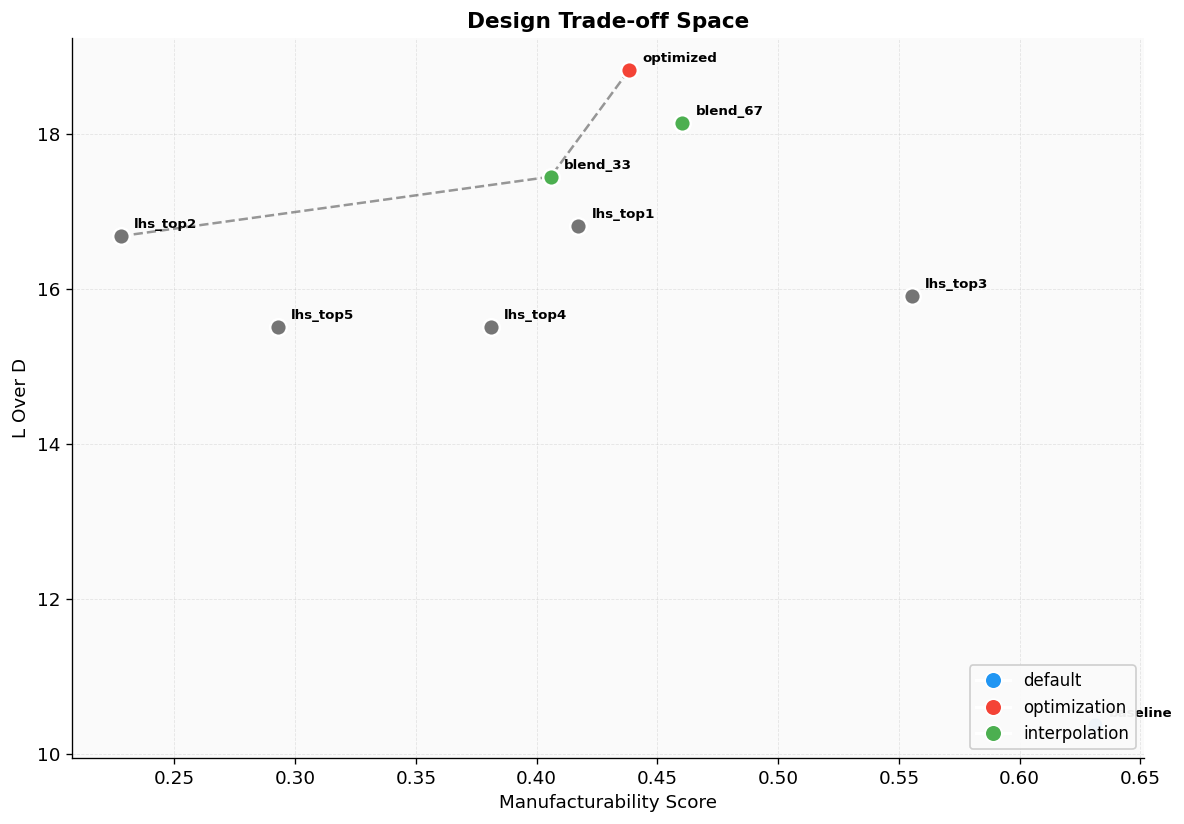

In [6]:
fig = plot_pareto(catalog, save_path='../output/catalog_pareto.png')

## 6. Radar Chart — Multi-Criteria Comparison

Normalized comparison across 6 dimensions: L/D, stability, manufacturability, volume, endurance, and structural mass.

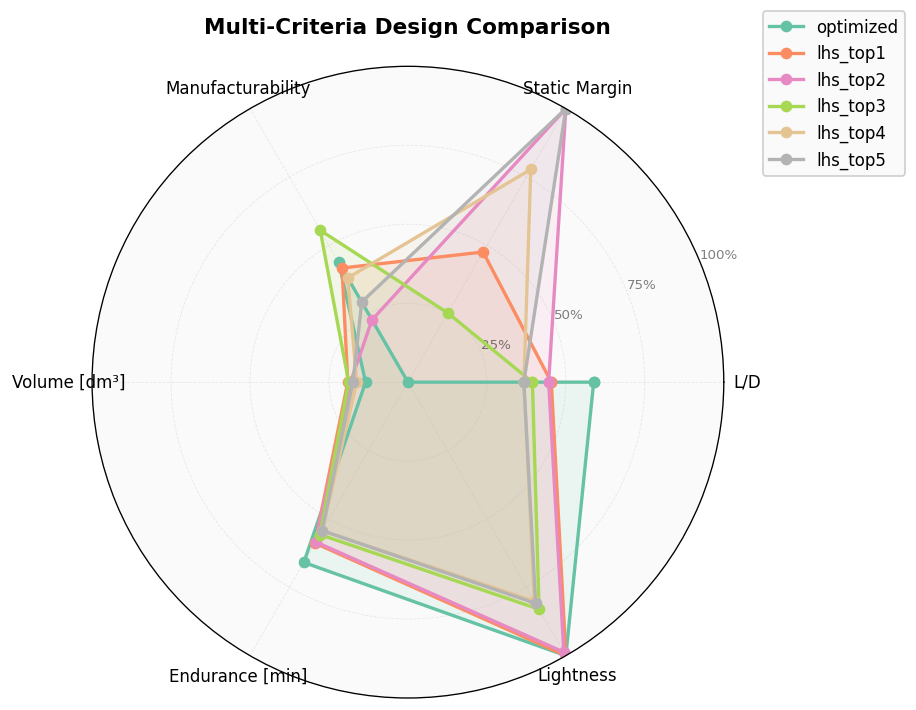

In [7]:
# Compare key designs: baseline, top LHS designs, blends, and optimized
radar_designs = [n for n in catalog.names if n != 'baseline'][:6]  # skip infeasible baseline
fig = plot_radar(catalog, designs=radar_designs,
                 save_path='../output/catalog_radar.png')
plt.show()

## 7. Geometric Comparison — Planform Overlays

Top view (planform) and front view (dihedral) superimposed for all catalog designs.

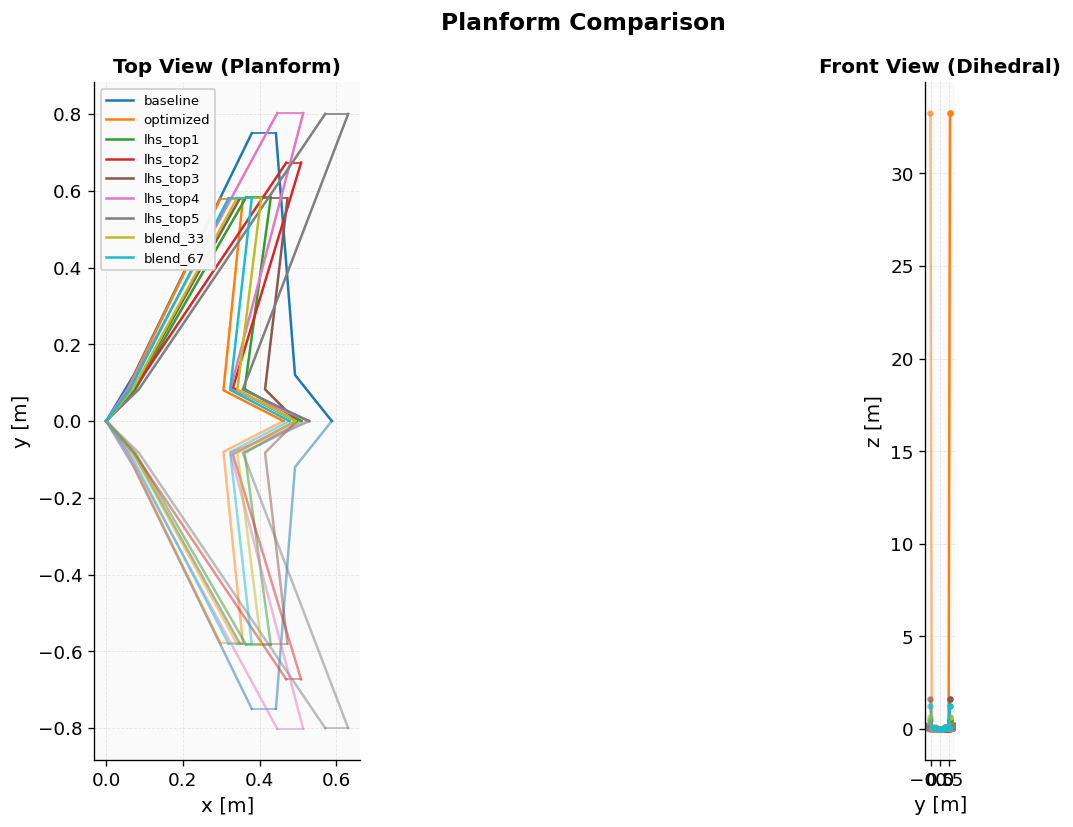

In [8]:
fig = plot_planform_overlay(catalog, save_path='../output/catalog_planforms.png')
plt.show()

## 8. Summary Table (visual)

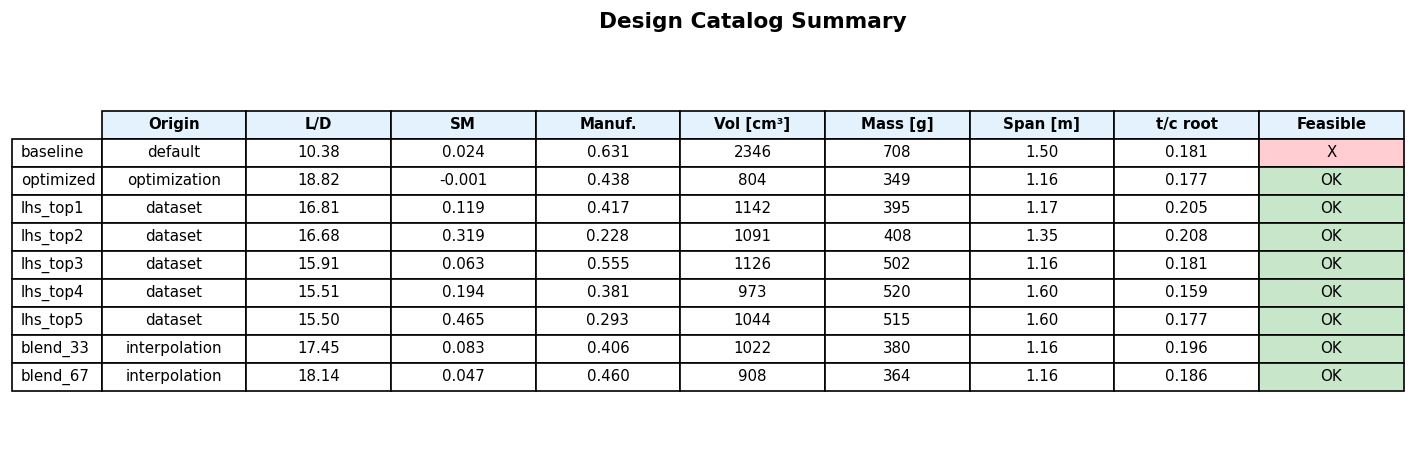

In [9]:
fig = plot_summary_table(catalog, save_path='../output/catalog_table.png')
plt.show()

In [10]:
# 9. Batch STEP Export
# Select which designs to export (uncomment to run — takes ~30s per design)
# paths = catalog.export_all_step(
#     output_dir='../output/catalog',
#     version='v2',
#     n_profile=100,
# )
# for name, path in paths.items():
#     print(f'  {name}: {path}')

In [11]:
# 10. Save Catalog
catalog.save('../output/catalog.json')
print(f'Catalog saved: {len(catalog)} designs → output/catalog.json')

# To reload in another session:
# catalog = DesignCatalog.load('../output/catalog.json')

Catalog saved: 9 designs → output/catalog.json
